# Nonlinear MPC: swinging up a cart-pole with multiple shooting and IPOPT

A cart-pole starts hanging down and must be swung up and balanced with a bounded force, on a
bounded track, by a nonlinear model-predictive controller that re-solves an optimal-control
problem every 50 ms. The problem is written once as a Scaly `Problem`; `sc.solver(..., "ipopt")`
turns it into a generated C wrapper around IPOPT with sparse derivative oracles.

| Scaly feature | Where |
| --- | --- |
| `sc.problem` with a variable *tree* `(states, inputs, slacks)` and per-leaf bounds | the OCP |
| `sc.vmap` of a one-stage `Function` | the shooting defects and stage costs: one loop, one stage's derivatives |
| `sc.bounded` inequality groups | the soft track limits |
| parameters (`params=`) | the measured state: one generated solver serves the whole closed loop |
| warm starts and `solver_stats()` | the receding-horizon loop |

This notebook needs the vendored IPOPT (`uv sync` builds it). The script version is
`examples/nmpc_cartpole.py`.

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import plotstyle
import scaly as sc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "nmpc_cartpole"

## Model

With cart position $p$, pole angle $\theta$ from upright, cart mass $M$, pole mass $m$ at distance
$\ell$ and force $u$ on the cart,

$$
\ddot p = \frac{u + m \ell \dot\theta^2 \sin\theta - m g \sin\theta\cos\theta}{M + m \sin^2\theta},\qquad
\ddot\theta = \frac{g \sin\theta\,(M + m) - \cos\theta\,(u + m \ell \dot\theta^2 \sin\theta)}{\ell\,(M + m\sin^2\theta)} .
$$

The controller's model $F(x, u)$ is two RK4 substeps over $\Delta t = 50$ ms; the "plant" used in
simulation integrates the same equations with ten substeps, so the model is slightly wrong, as in
reality.

In [2]:
NX, NU, DT = 4, 1, 0.05
M_CART, M_POLE, LENGTH, G = 1.0, 0.3, 0.5, 9.81
U_MAX, P_MAX = 15.0, 1.0
Q = np.array([2.0, 20.0, 0.1, 0.1])  # weights on p, 1 - cos(theta), rates
R, QN, SLACK_PENALTY = 0.02, 10.0, 1e3


def dynamics(x, u):
  theta, pd, td = x[1], x[2], x[3]
  s, c = theta.sin(), theta.cos()
  den = M_CART + M_POLE * s * s
  pdd = (u[0] + M_POLE * LENGTH * td * td * s - M_POLE * G * s * c) / den
  tdd = (G * s * (M_CART + M_POLE) - c * (u[0] + M_POLE * LENGTH * td * td * s)) / (LENGTH * den)
  return sc.stack([pd, td, pdd, tdd])


def rk4(x, u, h):
  k1 = dynamics(x, u)
  k2 = dynamics(x + 0.5 * h * k1, u)
  k3 = dynamics(x + 0.5 * h * k2, u)
  k4 = dynamics(x + h * k3, u)
  return x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


@sc.function(sc.G(sc.L("x", NX), sc.L("u", NU), sc.L("x_next", NX)), output=sc.L("defect", NX))
def defect(inputs):
  x, u, x_next = inputs
  return rk4(rk4(x, u, DT / 2), u, DT / 2) - x_next


@sc.function(sc.G(sc.L("x", NX), sc.L("u", NU)), output=sc.L("cost", 1))
def stage_cost(inputs):
  x, u = inputs
  e = sc.stack([x[0], 1 - x[1].cos(), x[2], x[3]])
  return ((sc.const(Q) * e * e).sum() + R * u[0] * u[0]).reshape((1,)) * DT

## The optimal-control problem

Multiple shooting keeps every state $x_0, \dots, x_N$ as a variable and imposes the dynamics as
equality constraints $F(x_k, u_k) - x_{k+1} = 0$:

$$
\begin{aligned}
\min_{x, u, s}\ & \sum_{k=0}^{N-1} \ell(x_k, u_k) + \ell_N(x_N) + \rho \sum_k s_k \\
\text{s.t.}\ & x_0 = \hat x, \quad F(x_k, u_k) = x_{k+1}, \quad |u_k| \le u_{\max}, \quad |p_k| \le p_{\max} + s_k, \quad s_k \ge 0 .
\end{aligned}
$$

The stage cost uses $1 - \cos\theta$, so both upright angles $0$ and $2\pi$ count as upright. The
track limit is *softened* by slacks with an exact $\ell_1$ penalty: with a hard state constraint,
the measured state (which comes from the plant, not the model) can make the problem infeasible.

The $N$ defects are **one** `sc.vmap` of the one-stage `defect` function over slices of the
decision vector: stage $k$ reads $x_k$ at offset $4k$, $u_k$ at offset $k$ and $x_{k+1}$ at offset
$4(k+1)$. IPOPT's sparse constraint Jacobian and Lagrangian Hessian are then built from the
derivatives of one stage, colored once, and evaluated in a loop.

In [3]:
def make_mpc(n):
  @sc.problem(vars=sc.G(sc.L("xs", (n + 1) * NX), sc.L("us", n * NU), sc.L("slack", n)), params=sc.L("x0", NX))
  def swing_up(variables, x0):
    xs, us, slack = variables
    defects = sc.vmap(defect, n, [(xs, 0, NX), (us, 0, NU), (xs, NX, NX)])
    costs = sc.vmap(stage_cost, n, [(xs, 0, NX), (us, 0, NU)])
    e = sc.stack([xs[n * NX], 1 - xs[n * NX + 1].cos(), xs[n * NX + 2], xs[n * NX + 3]])
    positions = xs.reshape((n + 1, NX))[1:, 0]
    return sc.ProblemSpec(
      minimize=costs.sum() + QN * (sc.const(Q) * e * e).sum() + SLACK_PENALTY * slack.sum(),
      eq=(xs[:NX] - x0, defects),
      ineq=(sc.bounded(positions - slack, hi=P_MAX, name="track_right"), sc.bounded(positions + slack, lo=-P_MAX, name="track_left")),
      lb=(sc.NO_LB, sc.const(np.full(n * NU, -U_MAX)), sc.const(np.zeros(n))),
      ub=(sc.NO_UB, sc.const(np.full(n * NU, U_MAX)), sc.NO_UB),
    )

  return swing_up, sc.solver(swing_up, "ipopt", name=f"cartpole_mpc_{n}", options={"tol": 1e-8, "max_iter": 500})


N = 40
problem, mpc = make_mpc(N)
print(f"{N} stages: {(N + 1) * NX + N * NU + N} variables, {problem.n_eq} equality and {problem.n_ineq} inequality constraints")

40 stages: 244 variables, 164 equality and 80 inequality constraints


## Closed loop

At each sample: solve from the measured state, apply the first input to the plant for 50 ms,
shift the solution one stage as the next initial guess, and keep the multipliers.

One subtlety: hanging still with $u \equiv 0$ is itself a KKT point of the first problem, by
symmetry, so a solver started there stays there. A pumping initial guess for the inputs breaks
the tie.

In [4]:
def plant_step(x, u, substeps=10):
  h = DT / substeps

  def f(x):
    theta, pd, td = x[1:]
    s, c = np.sin(theta), np.cos(theta)
    den = M_CART + M_POLE * s * s
    return np.array([pd, td, (u + M_POLE * LENGTH * td**2 * s - M_POLE * G * s * c) / den, (G * s * (M_CART + M_POLE) - c * (u + M_POLE * LENGTH * td**2 * s)) / (LENGTH * den)])

  for _ in range(substeps):
    k1 = f(x)
    k2 = f(x + 0.5 * h * k1)
    k3 = f(x + 0.5 * h * k2)
    k4 = f(x + h * k3)
    x = x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
  return x


SIM_STEPS = 120
x = np.array([0.0, np.pi, 0.0, 0.0])
guess = (np.tile(x, N + 1), 0.5 * U_MAX * np.sin(2 * np.pi * np.arange(N) / N), np.zeros(N))
lam_box = (np.zeros((N + 1) * NX), np.zeros(N * NU), np.zeros(N))
lam_eq, lam_ineq = np.zeros(problem.n_eq), np.zeros(problem.n_ineq)
states, inputs, iterations, times, statuses, first_plan = [x], [], [], [], [], None
for k in range(SIM_STEPS):
  (xs, us, slack), lam_box, lam_eq, lam_ineq = mpc(guess, lam_box, lam_eq, lam_ineq, x)
  stats = mpc.solver_stats()
  iterations.append(stats.iter)
  times.append(stats.t_total)
  statuses.append(stats.to_solver_status().name)
  if first_plan is None:
    first_plan = xs.reshape(N + 1, NX)
  x = plant_step(x, float(us[0]))
  states.append(x)
  inputs.append(float(us[0]))
  guess = (np.r_[xs[NX:], xs[-NX:]], np.r_[us[NU:], us[-NU:]], np.r_[slack[1:], slack[-1:]])
states, inputs, iterations, times = np.array(states), np.array(inputs), np.array(iterations), np.array(times)
print("IPOPT statuses:", dict(Counter(statuses)))
print(f"iterations: {iterations[0]} for the first solve, median {np.median(iterations[1:]):.0f} after; median solve {1e3 * np.median(times):.2f} ms")

IPOPT statuses: {'OK': 120}
iterations: 47 for the first solve, median 6 after; median solve 3.97 ms


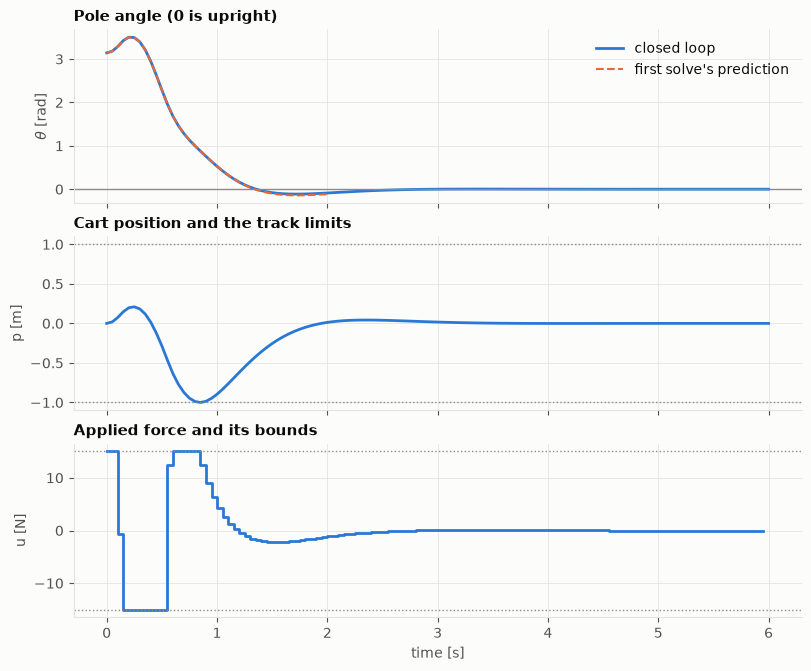

In [5]:
t = DT * np.arange(SIM_STEPS + 1)
fig, axes = plt.subplots(3, 1, figsize=(8, 6.6), sharex=True)
axes[0].plot(t, states[:, 1], color=plotstyle.BLUE, label="closed loop")
axes[0].plot(DT * np.arange(N + 1), first_plan[:, 1], "--", color=plotstyle.ORANGE, lw=1.5, label="first solve's prediction")
axes[0].axhline(0, color=plotstyle.NEUTRAL, lw=1)
axes[0].set_ylabel(r"$\theta$ [rad]")
axes[0].set_title("Pole angle (0 is upright)")
axes[0].legend(loc="upper right")
axes[1].plot(t, states[:, 0], color=plotstyle.BLUE)
for bound in (-P_MAX, P_MAX):
  axes[1].axhline(bound, color=plotstyle.NEUTRAL, lw=1, ls=":")
axes[1].set_ylabel("p [m]")
axes[1].set_title("Cart position and the track limits")
axes[2].step(t[:-1], inputs, where="post", color=plotstyle.BLUE)
for bound in (-U_MAX, U_MAX):
  axes[2].axhline(bound, color=plotstyle.NEUTRAL, lw=1, ls=":")
axes[2].set_ylabel("u [N]")
axes[2].set_title("Applied force and its bounds")
axes[2].set_xlabel("time [s]")
plt.show()

The controller needs a single pump: a push to the right, a hard push to the left that runs the cart
to the end of the track, and a push back to the right that brings the pole up over it. The pole is
upright after about 1.3 s and stays there. The first solve's open-loop prediction (dashed)
already contains the whole manoeuvre; the closed loop departs from it only slightly, because the
model is close to the plant.

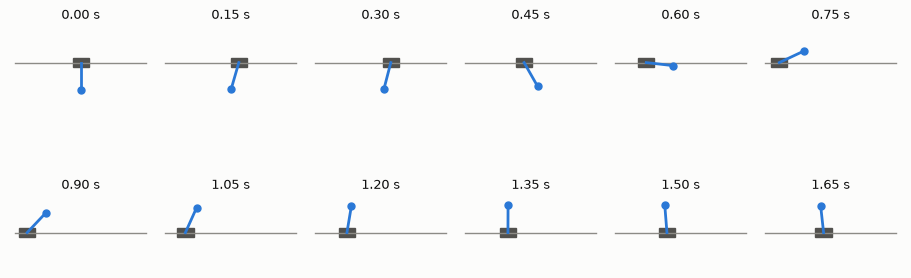

In [6]:
frames = np.arange(0, 36, 3)
fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
for ax, k in zip(axes.flat, frames, strict=True):
  p, theta = states[k, 0], states[k, 1]
  tip = (p + LENGTH * np.sin(theta), LENGTH * np.cos(theta))
  ax.plot([-P_MAX - 0.2, P_MAX + 0.2], [0, 0], color=plotstyle.NEUTRAL, lw=1)
  ax.add_patch(plt.Rectangle((p - 0.15, -0.08), 0.3, 0.16, color=plotstyle.TEXT_SECONDARY))
  ax.plot([p, tip[0]], [0, tip[1]], color=plotstyle.BLUE, lw=2)
  ax.plot(*tip, "o", color=plotstyle.BLUE, ms=5)
  ax.set_xlim(-1.3, 1.3)
  ax.set_ylim(-0.65, 0.65)
  ax.set_aspect("equal")
  ax.axis("off")
  ax.set_title(f"{t[k]:.2f} s", fontsize=9, fontweight="normal", loc="center")
plt.show()

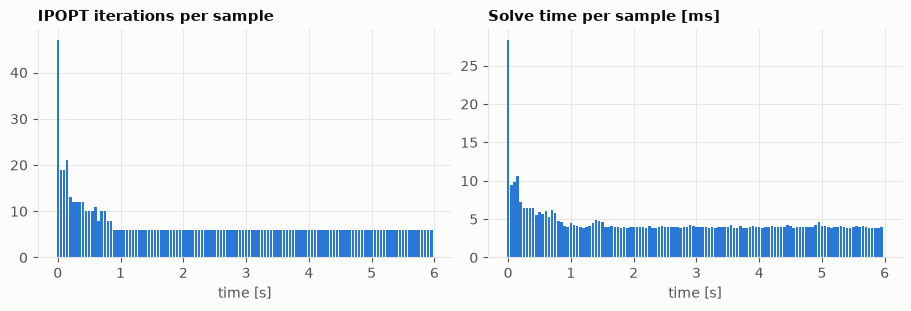

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.bar(t[:-1], iterations, width=0.8 * DT, color=plotstyle.BLUE)
ax1.set_title("IPOPT iterations per sample")
ax1.set_xlabel("time [s]")
ax2.bar(t[:-1], 1e3 * times, width=0.8 * DT, color=plotstyle.BLUE)
ax2.set_title("Solve time per sample [ms]")
ax2.set_xlabel("time [s]")
plt.show()

Warm starting pays off once the pole is up: six iterations per sample. The first solve, from a
crude guess, takes 47 iterations, and the swing-up, where the plan changes most from one sample to
the next, takes 10 to 20.

## Structure keeps the generated code small

Because the horizon is a `vmap`, the generated oracles contain one stage and a loop. Building the
same controller for different horizons shows that the C source grows far more slowly than $N$: an
eightfold longer horizon adds about half again, mostly the static index tables of the sparsity
patterns, which do grow with $N$.

In [8]:
for n in (20, 40, 80, 160):
  _, solver_n = make_mpc(n)
  module = write_module(solver_n, GENERATED / f"N{n}")
  print(f"N = {n:3d}: {len(module.source.splitlines()):5d} lines of C")

N =  20:  2065 lines of C


N =  40:  2403 lines of C


N =  80:  3083 lines of C


N = 160:  3065 lines of C


The generated sources are in `examples/generated/nmpc_cartpole/N*/`. They link against the
vendored IPOPT; `module.link_flags` has the flags.